**Обучение на частично размеченном датасете.  
Метод Self-Training.**


Евгений Борисов <esborisov@sevsu.ru>

---

$X,Y$ - учебный набор, частично размеченный;   
$X^ℓ = \lbrace x_1,\ldots, x_ℓ \rbrace$, $\lbrace y_1, \ldots, y_ℓ \rbrace$ - размеченная часть выборки (labeled data);    
$X^k = \lbrace x_{ℓ+1},\ldots, x_{ℓ+k} \rbrace$ - неразмеченная часть выборки (unlabeled data);	

$b_y(x)$ - оценка принадлежности объекта $x$ к классу $y$

классификатор - выбираем для объекта $x$ класс $y$ с наилучшей оценкой $b$ ;

$$a(x) = \arg \max_{у\in Y} b_y(x)$$

In [11]:
import numpy as np
from numpy import random as rng

# генерируем данные 

(1024, 2)

(1024,)

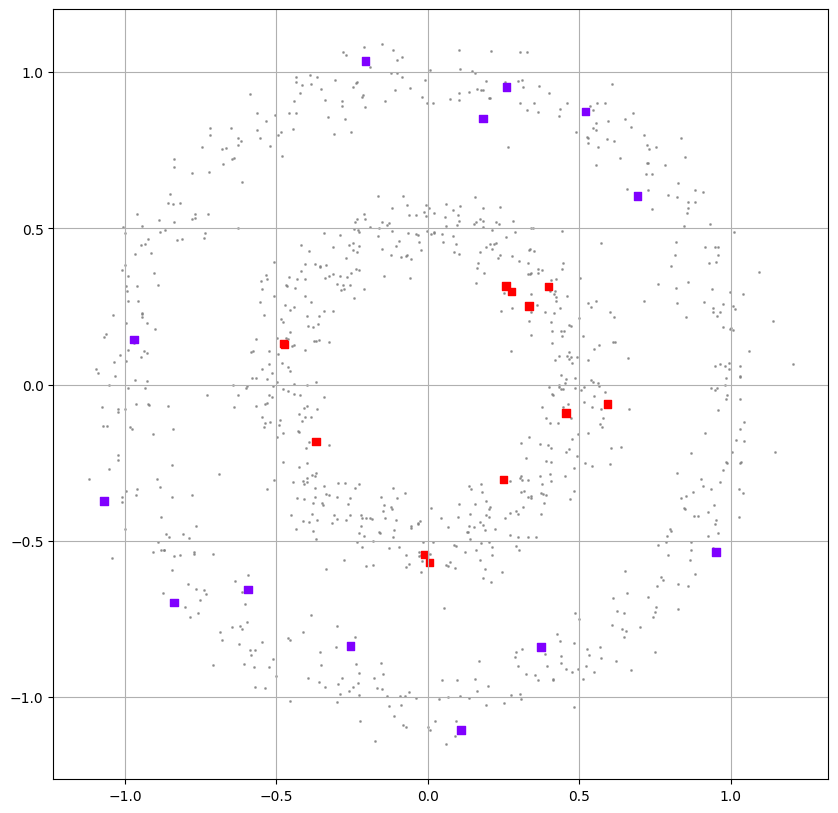

In [12]:

n_samples=1024

# генерируем датасет


# from sklearn.datasets import make_moons
# X, target = make_moons(n_samples=n_samples,noise=.1)

from sklearn.datasets import make_circles
X, target = make_circles(n_samples=n_samples,noise=.07,factor=0.5)
display( X.shape, target.shape )


# случайным образом делим датасет на размеченный и неразмеченный
from sklearn.model_selection import train_test_split

train_size=n_samples//40
( _, _, target_train, _, indices_train, indices_test ) = train_test_split( X, target, np.arange(n_samples), train_size=train_size )

# разметка должна содержать позитивные и негативные метки
assert 0 < target_train.sum() < train_size


from matplotlib import pyplot as plt

fig,ax = plt.subplots(1,figsize=(10,10))
ax.scatter(X[:,0],X[:,1],c='grey',s=1,alpha=0.7)
ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax.grid()
plt.show()

# "простой" классификатор

              precision    recall  f1-score   support

           0       0.98      0.70      0.82       512
           1       0.77      0.99      0.86       512

    accuracy                           0.84      1024
   macro avg       0.88      0.84      0.84      1024
weighted avg       0.88      0.84      0.84      1024



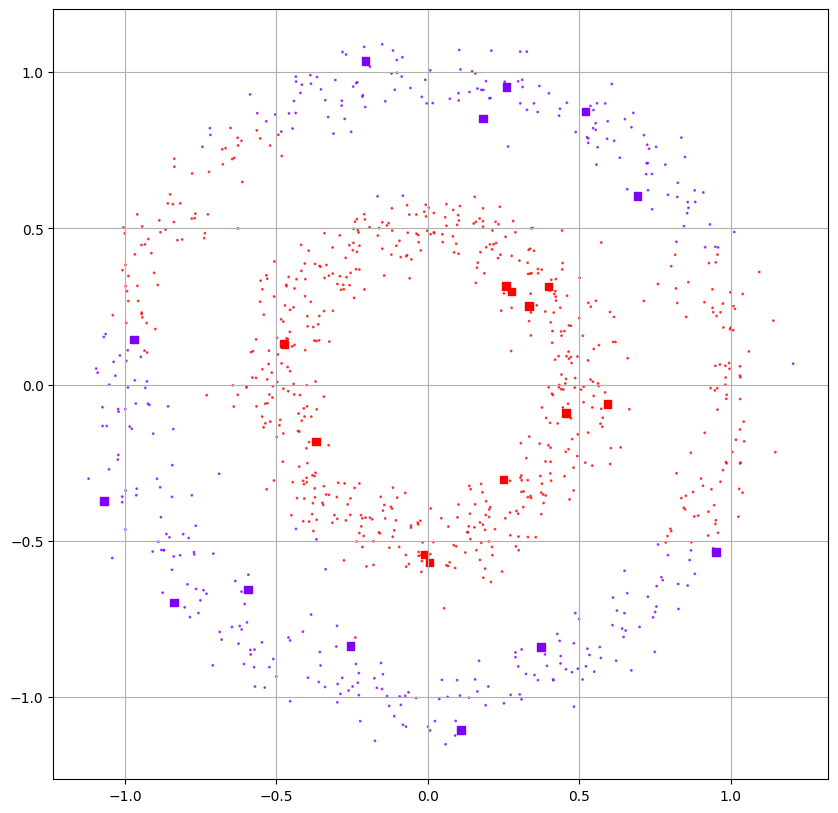

In [13]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier( n_neighbors=3, metric='euclidean', ).fit( X[indices_train,:], target_train )
p = model.predict(X)

from sklearn.metrics import classification_report
print(classification_report(y_true=target,y_pred=p))

fig,ax = plt.subplots(1,figsize=(10,10))
ax.scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=1,alpha=0.7)
ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax.grid()
plt.show()

# Self-Training классификатор

David Yarowsky    
Unsupervised word sense disambiguation rivaling supervised methods.    
Proceedings of the 33rd annual meeting on Association for Computational Linguistics (ACL ‘95).     
Association for Computational Linguistics, Stroudsburg, PA, USA, 189-196.   
https://dl.acm.org/doi/pdf/10.3115/981658.981684

---

оценка "степень доверия" классификации,  
насколько оценка класса-победителя лучше оценок остальных классов


$$ y = a(b(x)) $$
$$ M(x|a) = \max_{y\in Y} b_y(x) - \max_{q\in Y\setminus y}  b_q(x) $$

Алгоритм self-training — обёртка (wrapper) над произвольным методом обучения классификатора:
    

    
Z := Xℓ ;

пока |Z| < ℓ+k:  
- $a(b((Z))$ ; обучить классификатор $a$ на размеченных данных $Z$
- $X_∆ := \lbrace x\ |\ x \in X^k\setminus Z\ ; M(x|a) > M_0 \rbrace$ ; оценить неразмеченные и выбрать "надёжные"
- $y_∆ := \lbrace  a(x) | x \in X_∆ \rbrace $  ; доразметить "надёжные"
- $Z := Z \cup \lbrace X_∆, y_∆ \rbrace$ ; добавить новые к размеченным  


In [14]:
target_ = target.copy()
target_[indices_test] = -1  # помечаем объекты, для которых класс не определён

In [15]:
from tqdm.cli import tqdm

class SelfTrainingClassifier:

    def __init__(self, model_class, model_args):
        self._model_class = model_class
        self._model_args = model_args
        
    def fit(self,X,target):
        target_ = target.copy()
        for i in tqdm( range(len(target_)) ):
            # разделяем размеченные и неразмеченные
            indices_labeled = np.where(target_>-1)[0]
            indices_unlabeled = np.where(target_==-1)[0]

            # обучаем модель на размеченных
            model = self._model_class(**self._model_args).fit(X[indices_labeled],target_[indices_labeled])

            if len(indices_unlabeled)<1: break # все размечены, конец работы

            # считаем скор неразмеченных
            s = model.predict_proba(X[indices_unlabeled])
            # выбираем пример с максимальным скором
            n, c = np.unravel_index( np.argmax(s), s.shape )
            target_[indices_unlabeled[n]] = c # доразмечаем 
            del model 

        return model, target_

In [16]:
model, target__ = SelfTrainingClassifier( model_class=KNeighborsClassifier, model_args={ 'n_neighbors':1, 'metric':'euclidean',} ).fit(X,target_)

 98%|█████████▊| 999/1024 [00:02<00:00, 354.97it/s]


In [17]:
# # результат доразметки 
# fig,ax = plt.subplots(1,figsize=(10,10))
# ax.scatter(X[:,0],X[:,1],c=target__,cmap='rainbow',s=2,alpha=0.7)
# ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
# ax.set_title('результат доразметки')
# ax.grid()
# plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       512
           1       1.00      1.00      1.00       512

    accuracy                           1.00      1024
   macro avg       1.00      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



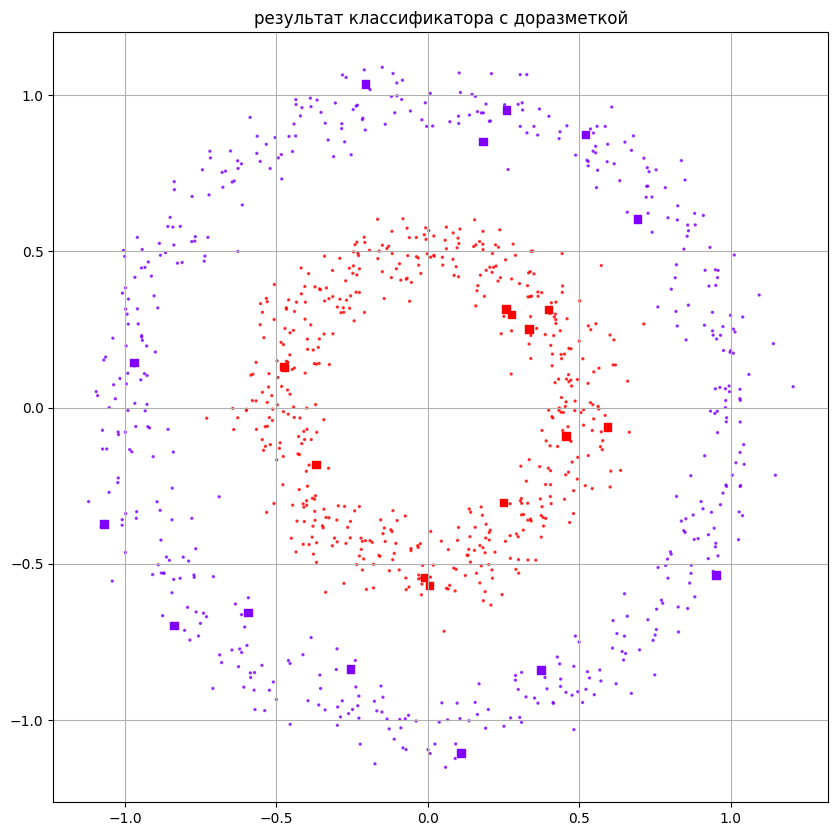

In [18]:
p = model.predict(X)
print(classification_report(y_true=target,y_pred=p))


fig,ax = plt.subplots(1,figsize=(10,10))
ax.scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=2,alpha=0.7)
ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax.set_title('результат классификатора с доразметкой')
ax.grid()
plt.show()

In [21]:
# from sklearn.semi_supervised import SelfTrainingClassifier
# from sklearn.neighbors import KNeighborsClassifier


# model_ = SelfTrainingClassifier( estimator=KNeighborsClassifier(n_neighbors=1, metric='euclidean',), criterion='threshold', threshold=.69,max_iter=256 ).fit( X, target_ )
# # model_ = SelfTrainingClassifier( KNeighborsClassifier(n_neighbors=3, metric='euclidean',),criterion='k_best',k_best=1,max_iter=128).fit(X,target_)

# p = model_.predict(X)
# print(classification_report(y_true=target,y_pred=p))


# fig,ax = plt.subplots(1,figsize=(10,10))
# ax.scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=2,alpha=0.7)
# ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
# ax.grid()
# plt.show()

# LabelPropagation

Xiaojin Zhu and Zoubin Ghahramani.   
Learning from labeled and unlabeled data with label propagation.   
Technical Report CMU-CALD-02-107, Carnegie Mellon University, 2002   
http://pages.cs.wisc.edu/~jerryzhu/pub/CMU-CALD-02-107.pdf

Label Propagation Algorithm and its Application.  
Dezhou Chen  
Jul 15, 2021   
https://medium.com/@dezhouc2/label-propagation-algorithm-and-its-application-162d03f10d3a

In [22]:
# from sklearn.semi_supervised import LabelPropagation

# model = LabelPropagation().fit(X,target_)

# p = model.predict(X)
# print(classification_report(y_true=target,y_pred=p))


# fig,ax = plt.subplots(1,figsize=(10,10))
# ax.scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=2,alpha=0.7)
# ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
# ax.set_title('результат классификатора с доразметкой')
# ax.grid()
# plt.show()